In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 60, 3, padding=1, groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model30_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model30_0)
describe(model30_0)

MACs: 6.11 MMac, Params: 29.25 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model30_0.pt
Starting
Epoch 1/60: Train loss = 1.3993, Train accuracy = 0.5149, Test loss = 1.3055, Test accuracy = 0.5413
Epoch 2/60: Train loss = 0.9643, Train accuracy = 0.6580, Test loss = 0.9531, Test accuracy = 0.6641
Epoch 3/60: Train loss = 0.8653, Train accuracy = 0.6960, Test loss = 0.8696, Test accuracy = 0.6996
Epoch 4/60: Train loss = 0.7862, Train accuracy = 0.7220, Test loss = 0.7782, Test accuracy = 0.7273
Epoch 5/60: Train loss = 0.7934, Train accuracy = 0.7214, Test loss = 0.7839, Test accuracy = 0.7302
Epoch 6/60: Train loss = 0.7476, Train accuracy = 0.7371, Test loss = 0.7657, Test accuracy = 0.7332
Epoch 7/60: Train loss = 0.6669, Train accuracy = 0.7657, Test loss = 0.6682, Test accuracy = 0.7701
Epoch 8/60: Train loss = 0.6216, Train accuracy = 0.7796, Test loss = 0.6398, Test accuracy = 0.7783
Epoch 9/60: Train loss = 0.6071, Train accuracy = 0.7874, Test loss = 0.6350, Test accuracy = 0.7829
Epoch 10/60: Train loss = 0.678

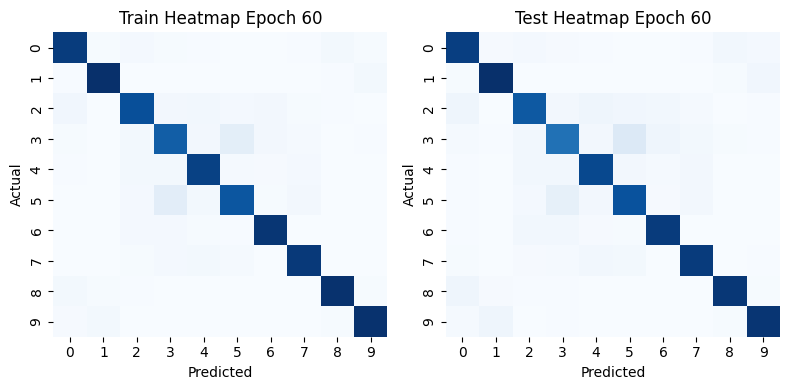

<Figure size 1200x600 with 0 Axes>

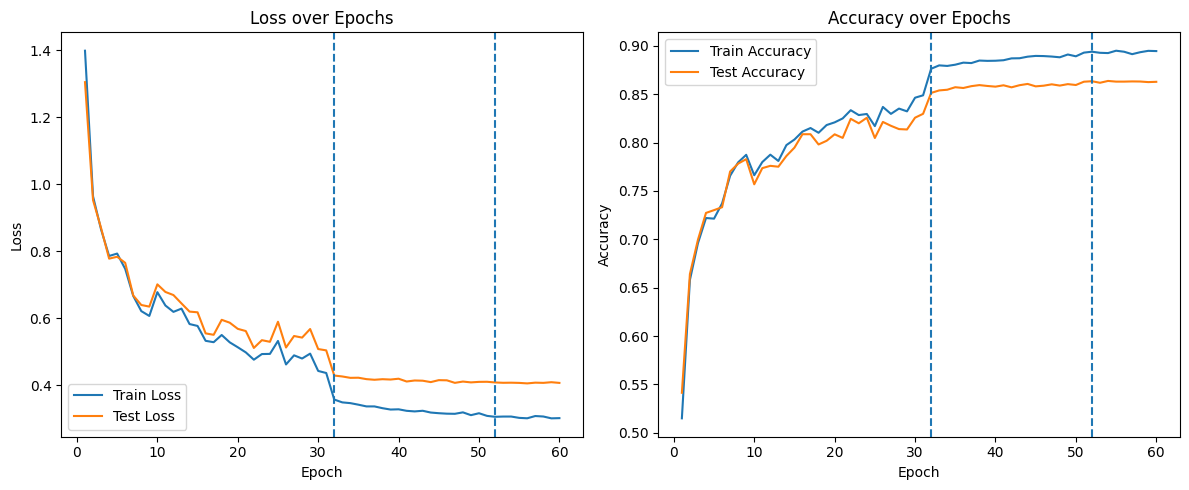

In [6]:
trainf32(model30_0,"model_weights/model30_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model30_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model30_1)
describe(model30_1)

MACs: 6.11 MMac, Params: 29.25 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model30_1.pt
Starting
Epoch 1/60: Train loss = 1.2464, Train accuracy = 0.5643, Test loss = 1.2369, Test accuracy = 0.5736
Epoch 2/60: Train loss = 0.9455, Train accuracy = 0.6698, Test loss = 0.9426, Test accuracy = 0.6740
Epoch 3/60: Train loss = 0.8017, Train accuracy = 0.7188, Test loss = 0.7798, Test accuracy = 0.7254
Epoch 4/60: Train loss = 0.7484, Train accuracy = 0.7361, Test loss = 0.7484, Test accuracy = 0.7401
Epoch 5/60: Train loss = 0.7039, Train accuracy = 0.7544, Test loss = 0.6989, Test accuracy = 0.7580
Epoch 6/60: Train loss = 0.7551, Train accuracy = 0.7345, Test loss = 0.7635, Test accuracy = 0.7377
Epoch 7/60: Train loss = 0.6314, Train accuracy = 0.7791, Test loss = 0.6331, Test accuracy = 0.7889
Epoch 8/60: Train loss = 0.6065, Train accuracy = 0.7882, Test loss = 0.6241, Test accuracy = 0.7869
Epoch 9/60: Train loss = 0.6362, Train accuracy = 0.7752, Test loss = 0.6437, Test accuracy = 0.7788
Epoch 10/60: Train loss = 0.594

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 25/60: Train loss = 0.4730, Train accuracy = 0.8374, Test loss = 0.5165, Test accuracy = 0.8258
Epoch 26/60: Train loss = 0.4453, Train accuracy = 0.8453, Test loss = 0.4884, Test accuracy = 0.8321
Epoch 27/60: Train loss = 0.4459, Train accuracy = 0.8422, Test loss = 0.4880, Test accuracy = 0.8313
Epoch 28/60: Train loss = 0.4522, Train accuracy = 0.8405, Test loss = 0.4977, Test accuracy = 0.8270
Epoch 29/60: Train loss = 0.4560, Train accuracy = 0.8437, Test loss = 0.4936, Test accuracy = 0.8278
Epoch 30/60: Train loss = 0.4428, Train accuracy = 0.8465, Test loss = 0.4832, Test accuracy = 0.8316
Epoch 31/60: Train loss = 0.4485, Train accuracy = 0.8428, Test loss = 0.5047, Test accuracy = 0.8288
Epoch 32/60: Train loss = 0.3657, Train accuracy = 0.8725, Test loss = 0.4184, Test accuracy = 0.8534
Epoch 33/60: Train loss = 0.3546, Train accuracy = 0.8763, Test loss = 0.4153, Test accuracy = 0.8570
Epoch 34/60: Train loss = 0.3465, Train accuracy = 0.8802, Test loss = 0.4102, Tes

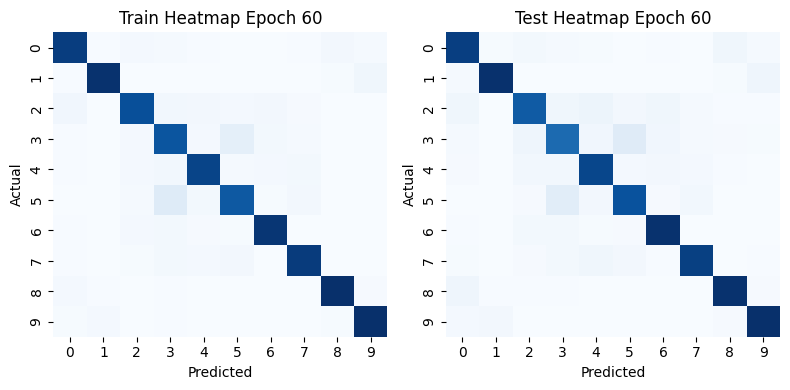

<Figure size 1200x600 with 0 Axes>

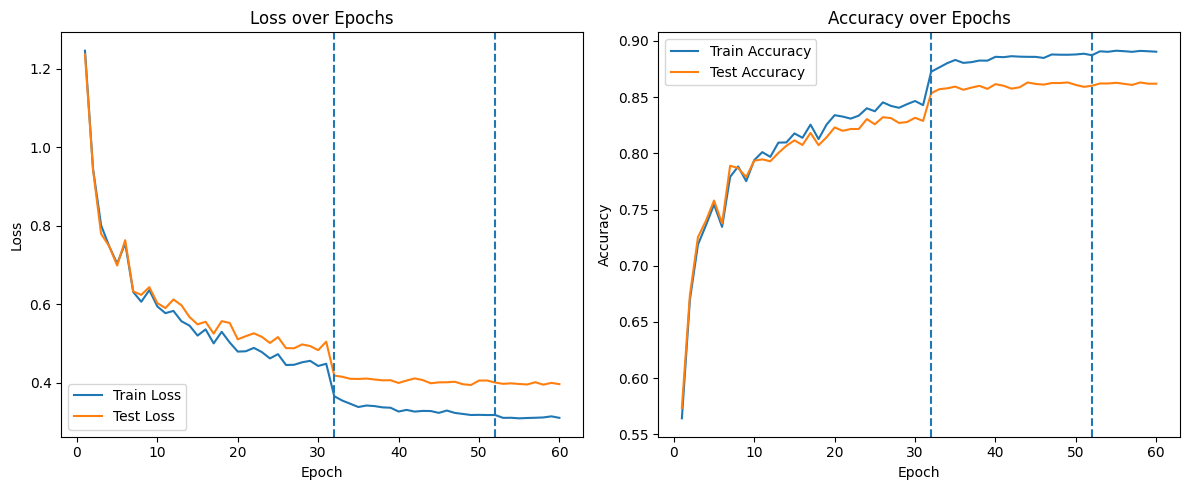

In [8]:
trainf32(model30_1,"model_weights/model30_1.pt",criterion,train_dataset,val_dataset, batch_size=64)